# Feature Engineering

This notebook converts the cleaned lagged dataset into a smaller set of economically meaningful modelling features. The purpose is to create composite indicators, reduce distortion from skewed variables, inspect relationships with GDP growth, and export a feature set that is easier to model than the raw inputs.


## Distribution Review

Before creating new features, this section checks how the cleaned variables are distributed. The goal is to identify skew and scaling problems that could weaken simple linear models.


In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#linear regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
#k-nearest neighbors regressor
from sklearn.neighbors import KNeighborsRegressor
#random forest regressor
from sklearn.ensemble import RandomForestRegressor
# evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error
#gradient boosting regressor
from sklearn.ensemble import GradientBoostingRegressor
# pipelines
from sklearn.pipeline import Pipeline
#scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler

## Creating Derived Economic Features

These engineered variables compress broader economic stories into a few columns. They are designed to capture borrowing conditions, external balance, and exchange-rate movement in a form that can be tested more directly against GDP growth.


In [142]:
df["real_interest_rate"] = (
    df["lending_interest_rate(%)_lag1"] 
    - df["inflation_rate(%)_lag1"]
)

In [143]:
df["economic_stress"] = (
    df["inflation_rate(%)_lag1"] 
    + df["under_earning_percentage(%)_lag1"] + df["unemployment_rate(%)_lag1"]
) / 3

In [144]:
df["export_import_ratio"] = (df["export_of_goods_and_services(US$)_lag1"] / df["import_of_goods_and_services(US$)_lag1"])

In [145]:
df["exchange_rate_change_lag1"] = df["exchange_rate(IDR/US$)_lag1"].pct_change().bfill()

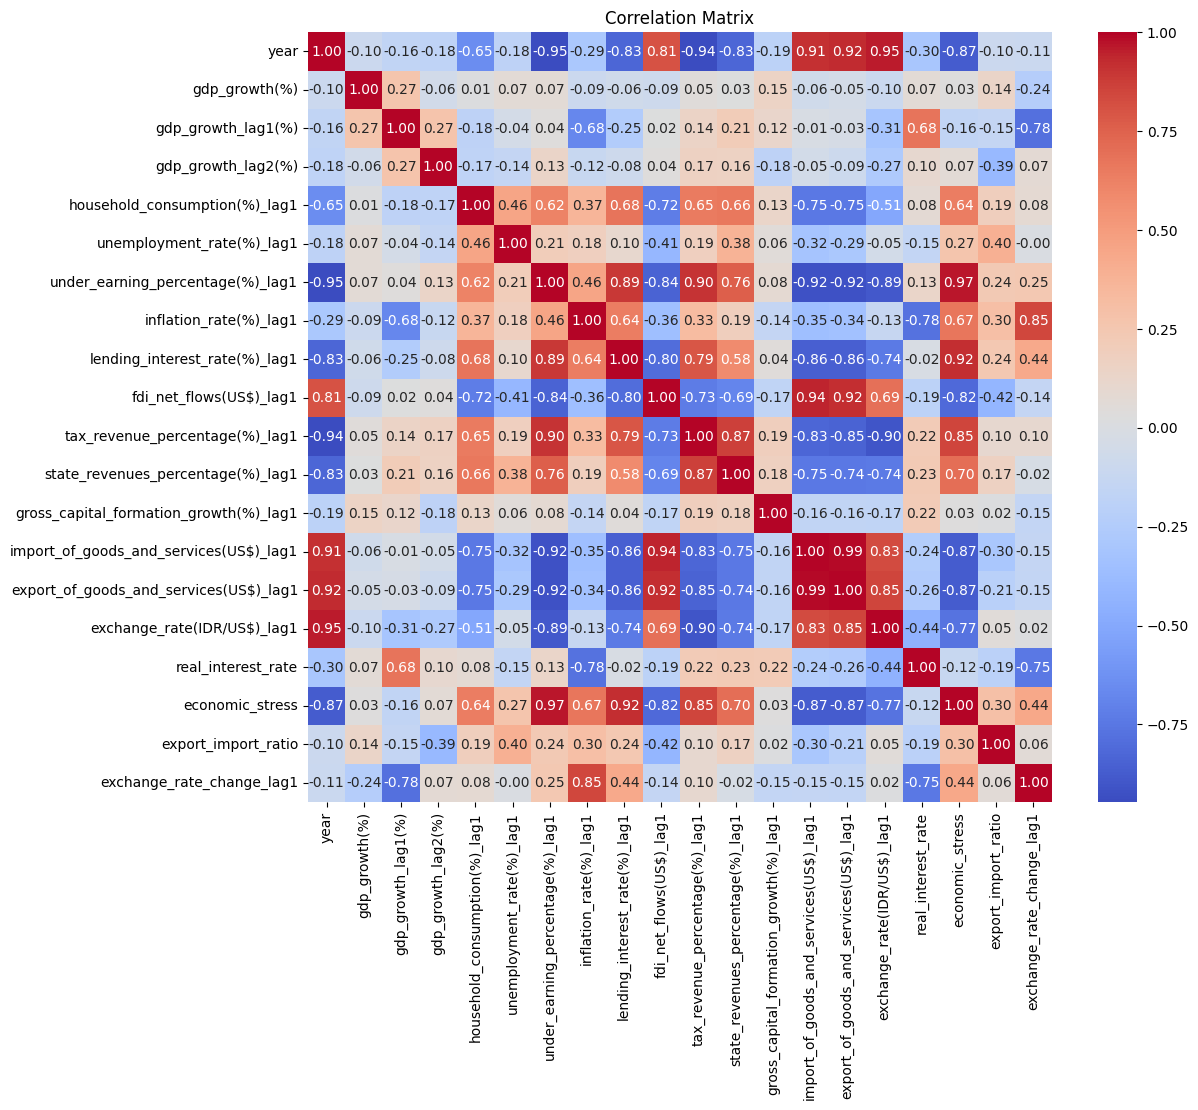

In [146]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

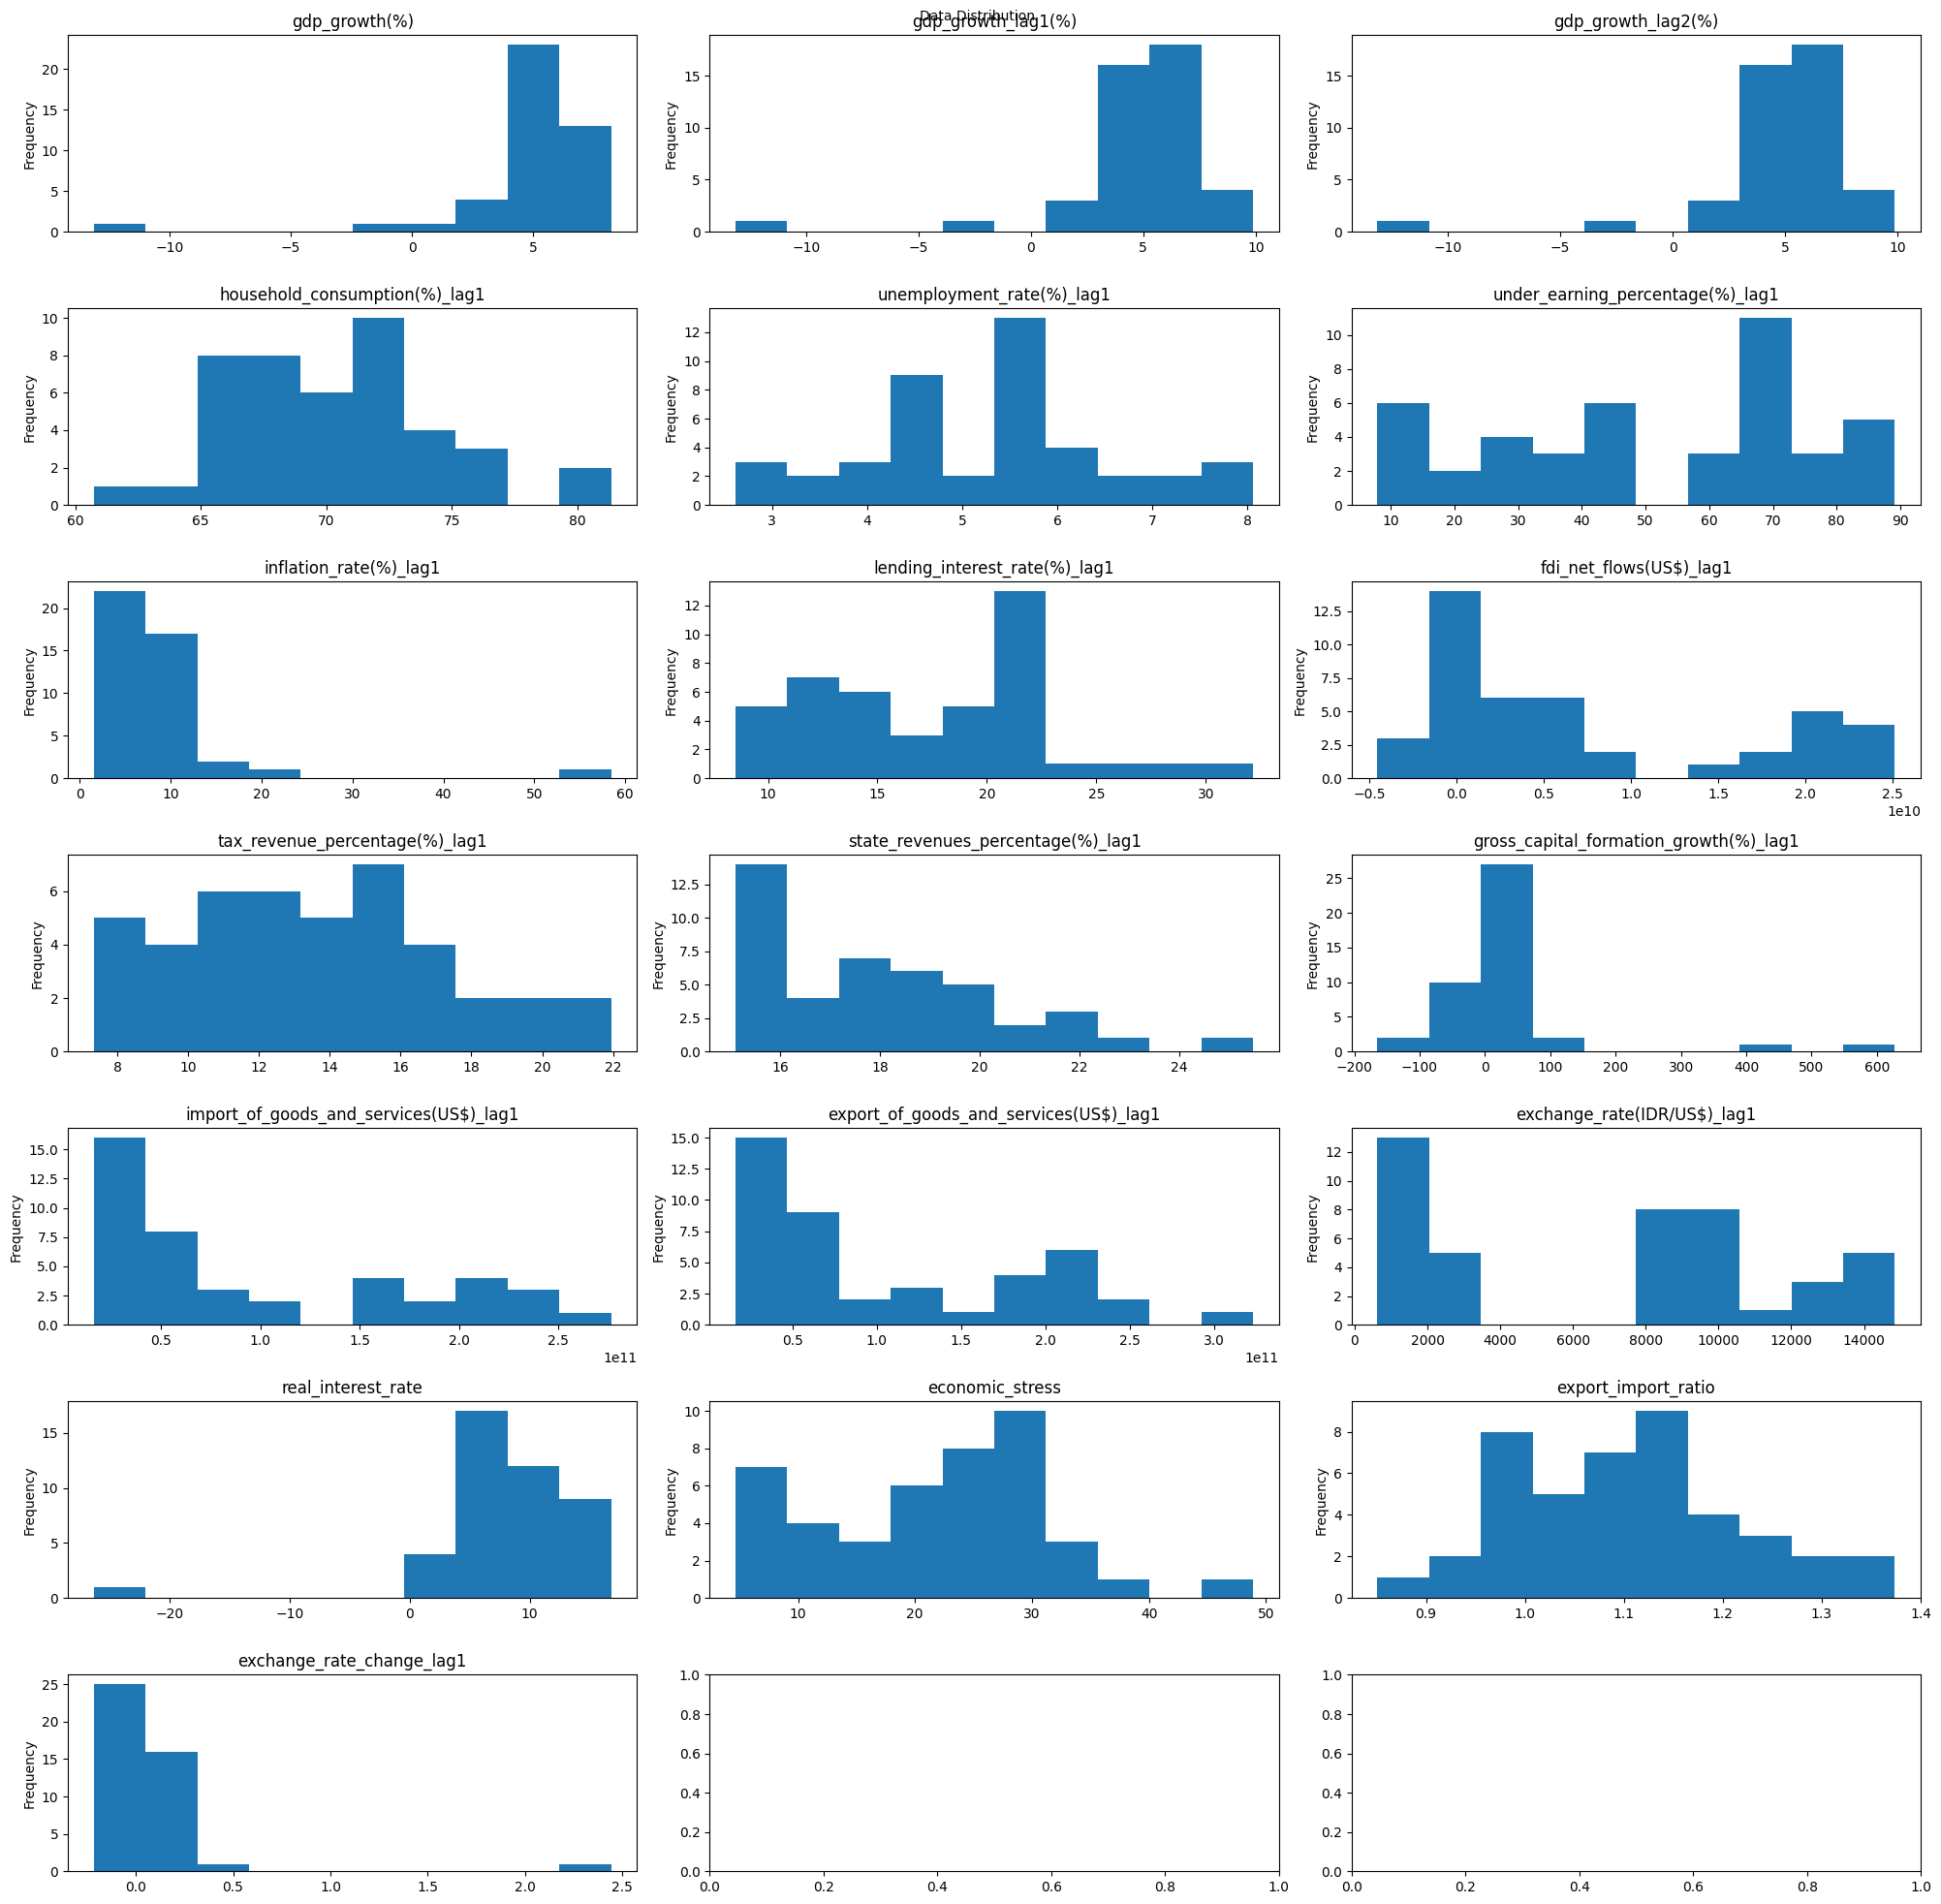

In [147]:

def show_dist(df):
    labels = df.columns[1:]
    fig, axes = plt.subplots(7,3, sharex=False, figsize=(20,20))
    axes = axes.flatten() 

    fig.suptitle("Data Distribution", fontsize=10)

    for index, label in enumerate(labels):
        df[label].plot(kind="hist", ax=axes[index])
        axes[index].set_title(label)


    fig.tight_layout()

show_dist(df)

/opt/miniconda3/envs/dlenv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


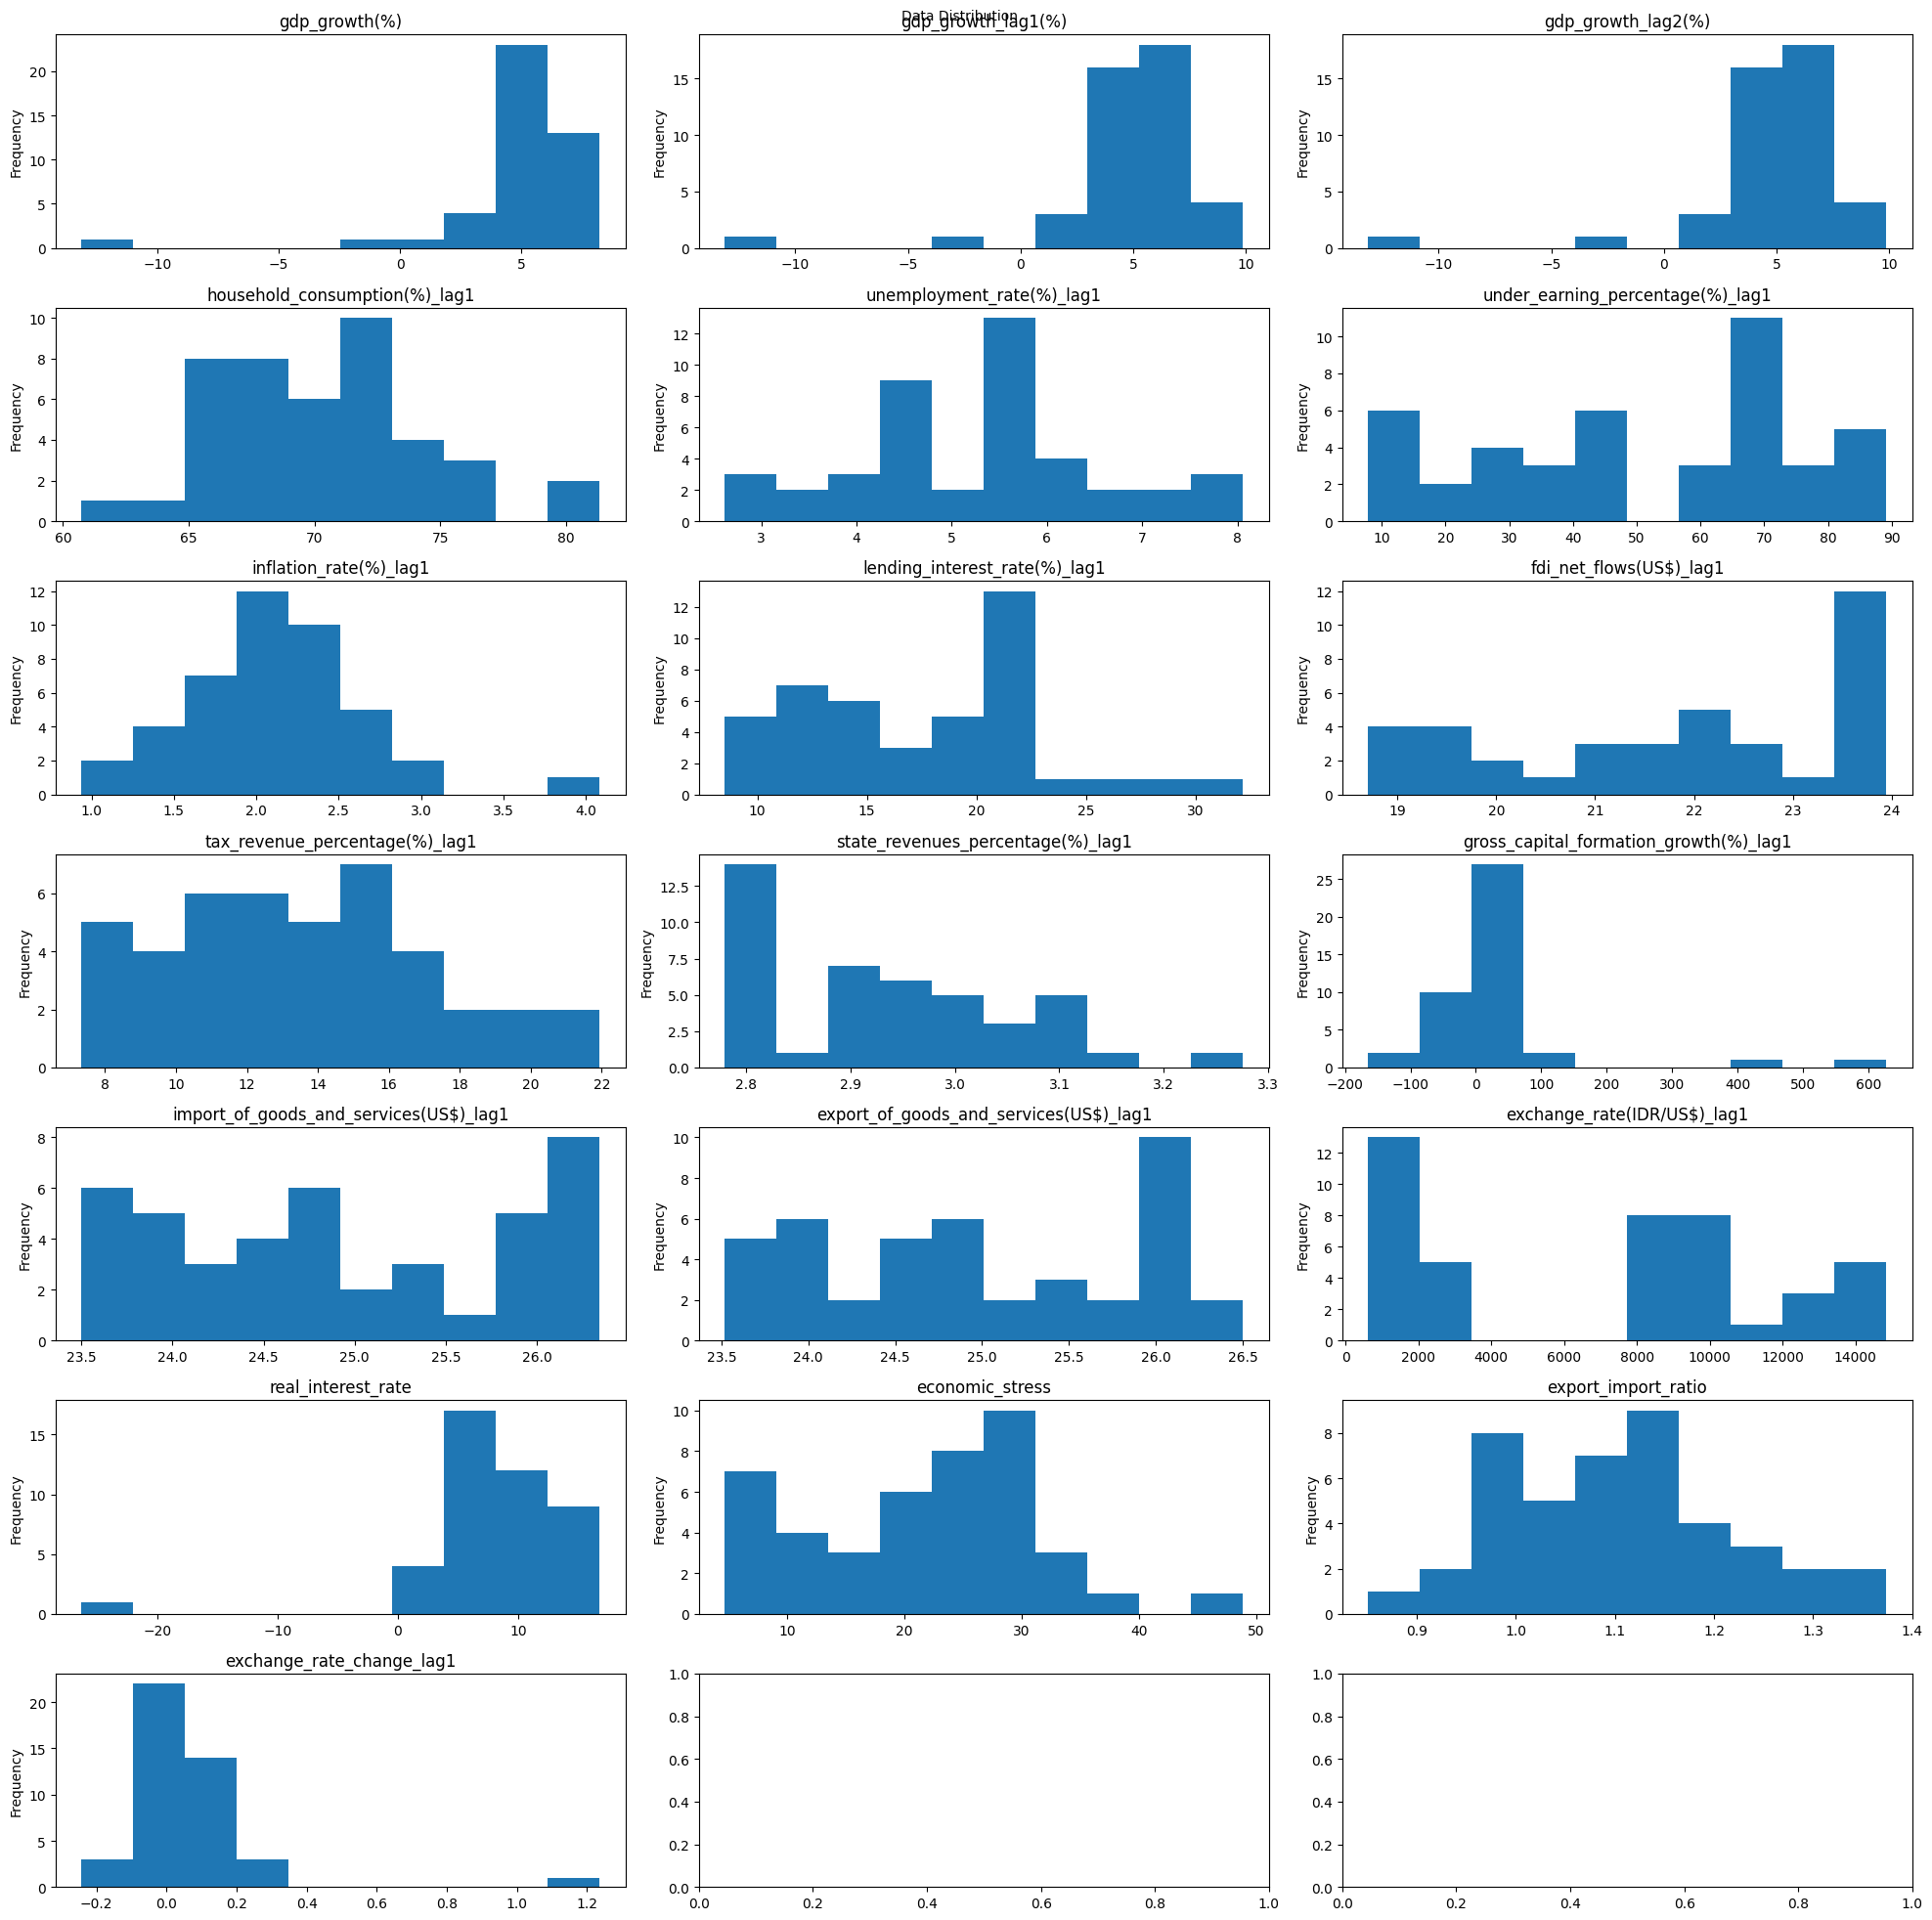

In [148]:
# Reduce skew in heavily right-tailed variables so the later linear models are less dominated by scale.
skewed_features = [
    "fdi_net_flows(US$)_lag1",
    "import_of_goods_and_services(US$)_lag1",
    "export_of_goods_and_services(US$)_lag1",
    "state_revenues_percentage(%)_lag1",
    "exchange_rate_change_lag1",
    "inflation_rate(%)_lag1"
]

for col in skewed_features:
    df[col] = np.log1p(df[col])

show_dist(df)


## Feature Selection

After engineering the new variables, this section compares their correlations with current and next-year GDP growth. The objective is not to claim causality, but to keep the most informative signals and remove obvious redundancy before modelling.


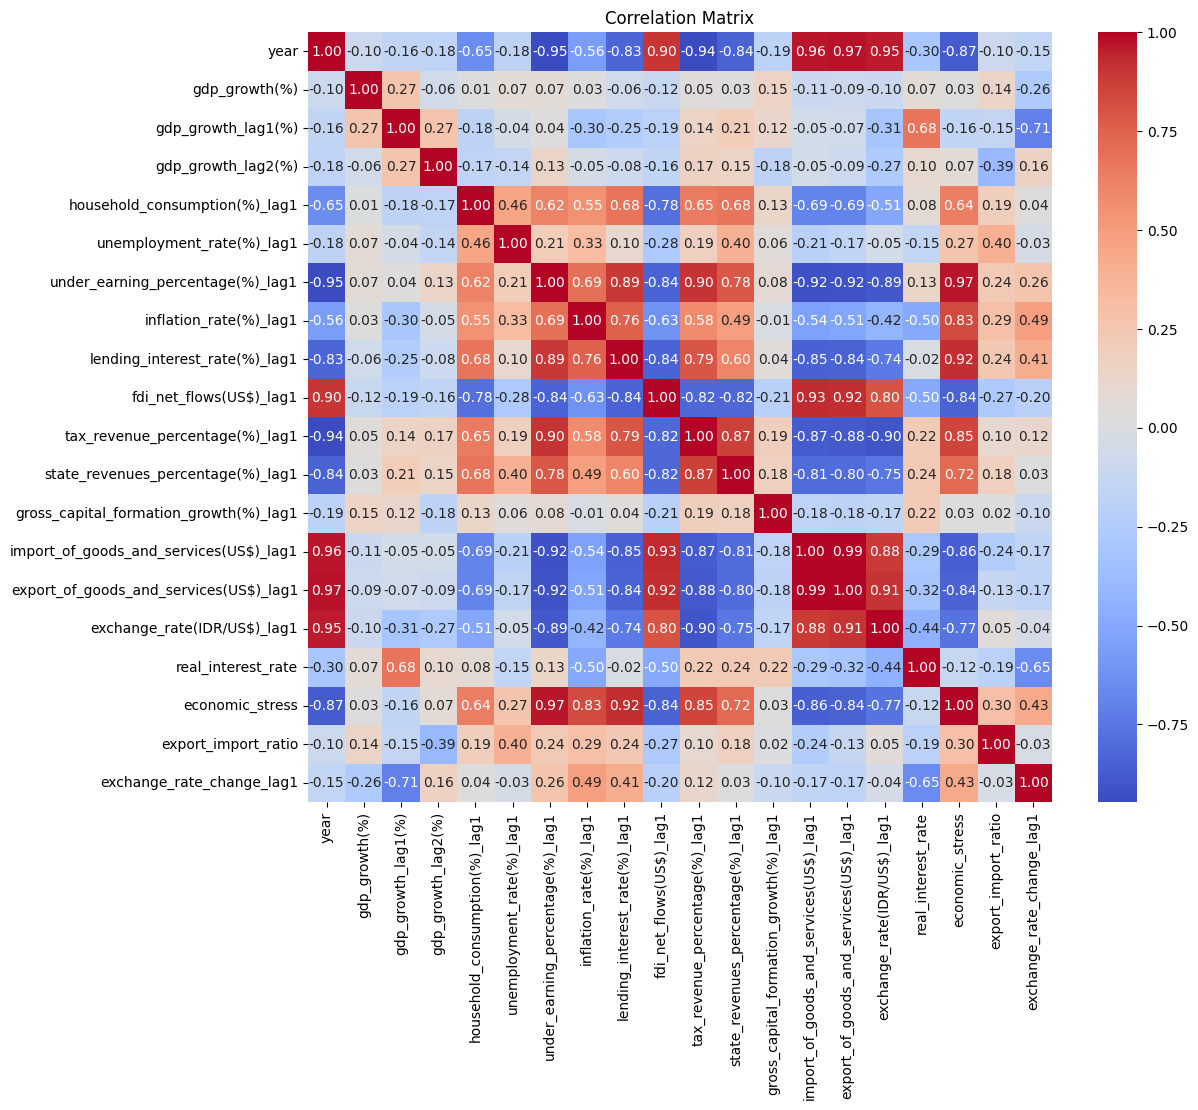

In [150]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [151]:
corr = df.corr()["gdp_growth(%)"].sort_values(ascending=False)
print("Next Year\n")
print(corr)

Next Year

gdp_growth(%)                             1.000000
gdp_growth_lag1(%)                        0.269595
gross_capital_formation_growth(%)_lag1    0.148687
export_import_ratio                       0.138487
real_interest_rate                        0.070735
under_earning_percentage(%)_lag1          0.070157
unemployment_rate(%)_lag1                 0.067329
tax_revenue_percentage(%)_lag1            0.045129
inflation_rate(%)_lag1                    0.033932
economic_stress                           0.033911
state_revenues_percentage(%)_lag1         0.031557
household_consumption(%)_lag1             0.014412
gdp_growth_lag2(%)                       -0.057745
lending_interest_rate(%)_lag1            -0.064531
export_of_goods_and_services(US$)_lag1   -0.091709
year                                     -0.099825
exchange_rate(IDR/US$)_lag1              -0.104132
import_of_goods_and_services(US$)_lag1   -0.106097
fdi_net_flows(US$)_lag1                  -0.121687
exchange_rate_change

In [152]:
corr = df.corr()["gdp_growth_lag1(%)"].sort_values(ascending=False)
print("Current Year\n")
print(corr)

Current Year

gdp_growth_lag1(%)                        1.000000
real_interest_rate                        0.676138
gdp_growth_lag2(%)                        0.274300
gdp_growth(%)                             0.269595
state_revenues_percentage(%)_lag1         0.206764
tax_revenue_percentage(%)_lag1            0.142260
gross_capital_formation_growth(%)_lag1    0.124159
under_earning_percentage(%)_lag1          0.041426
unemployment_rate(%)_lag1                -0.043616
import_of_goods_and_services(US$)_lag1   -0.053848
export_of_goods_and_services(US$)_lag1   -0.071436
export_import_ratio                      -0.145891
year                                     -0.157754
economic_stress                          -0.160520
household_consumption(%)_lag1            -0.182172
fdi_net_flows(US$)_lag1                  -0.194410
lending_interest_rate(%)_lag1            -0.253094
inflation_rate(%)_lag1                   -0.304246
exchange_rate(IDR/US$)_lag1              -0.314470
exchange_rate_cha

## Interpreting the Correlation Results

This summary translates the correlation tables into plain-language modelling choices. It documents which variables appear to support growth, which move against it, and why the final feature subset is narrower than the original cleaned dataset.


The selected feature set keeps variables that are either economically interpretable, predictive in the correlation scan, or useful for preserving the forecasting structure of the dataset.


In [153]:
# Keep the features that best balance interpretability and correlation strength for the forecasting task.
selected_features = [

    "real_interest_rate",
    "lending_interest_rate(%)_lag1",
    "inflation_rate(%)_lag1",
    "exchange_rate_change_lag1",
    "export_import_ratio",
    "gross_capital_formation_growth(%)_lag1",
    "fdi_net_flows(US$)_lag1",
    "state_revenues_percentage(%)_lag1",
    "gdp_growth_lag2(%)",
    "gdp_growth_lag1(%)",
    "gdp_growth(%)",
]

# 2. Filter the DataFrame
selected_features_df = df[selected_features]

# 3. View the result
selected_features_df.head()


,real_interest_rate,lending_interest_rate(%)_lag1,inflation_rate(%)_lag1,exchange_rate_change_lag1,export_import_ratio,gross_capital_formation_growth(%)_lag1,fdi_net_flows(US$)_lag1,state_revenues_percentage(%)_lag1,gdp_growth_lag2(%),gdp_growth_lag1(%),gdp_growth(%)
0,3.468745,21.504167,2.946302,0.007567,1.373956,24.369558,19.008467,3.173780,6.165775,9.880078,7.927157
1,9.238259,21.504167,2.585197,0.007567,1.081559,12.398103,18.705860,3.276174,9.880078,7.927157,2.246445
2,12.058741,21.504167,2.346164,0.045886,0.851005,5.647824,19.231611,3.113067,7.927157,2.246445,4.192967
3,9.704428,21.504167,2.549425,0.318246,0.962920,627.499564,19.492264,3.093168,2.246445,4.192967,6.975528
4,11.049127,21.504167,2.438430,0.120733,1.198254,52.568955,19.218188,3.113884,4.192967,6.975528,2.462144


In [154]:
selected_features_df['fdi_net_flows(US$)_lag1'].interpolate(method='linear', inplace=True)

/var/folders/tk/mn4_r_cn03ndtjss8b670dfw0000gn/T/ipykernel_65592/1161348818.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  selected_features_df['fdi_net_flows(US$)_lag1'].interpolate(method='linear', inplace=True)
/var/folders/tk/mn4_r_cn03ndtjss8b670dfw0000gn/T/ipykernel_65592/1161348818.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


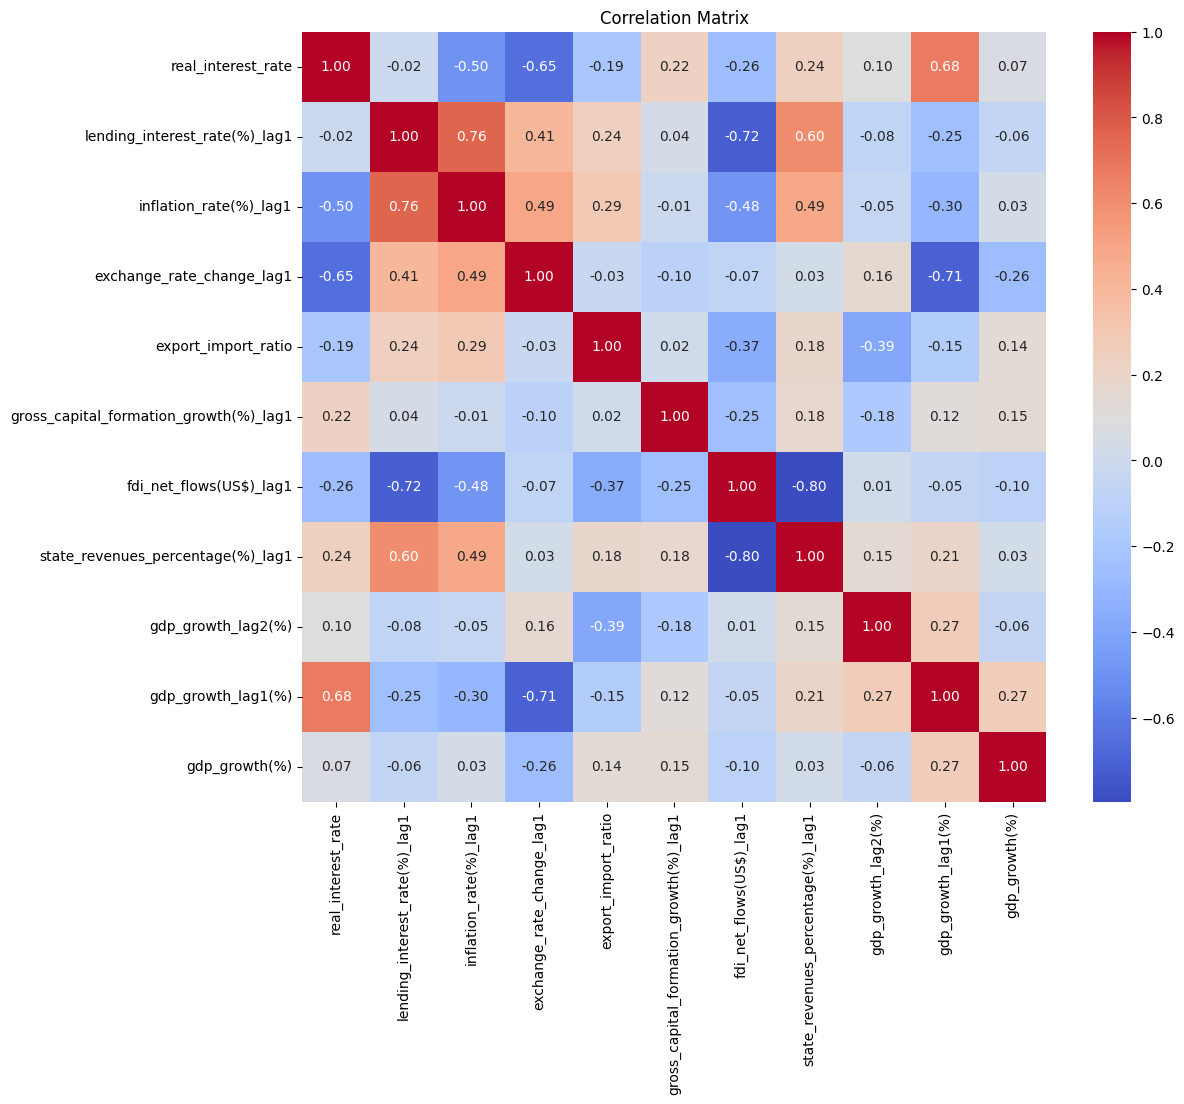

In [156]:
plt.figure(figsize=(12, 10))
sns.heatmap(selected_features_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [157]:
selected_features_df.to_csv("feature_engineered_gdp_growth_lag1.csv", index=False)